In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
np.random.seed(42)

# Class 0
X0 = np.random.randn(50, 2) + np.array([2, 2])

# Class 1
X1 = np.random.randn(50, 2) + np.array([6, 6])

X = np.vstack((X0, X1))
y = np.hstack((np.zeros(50), np.ones(50)))

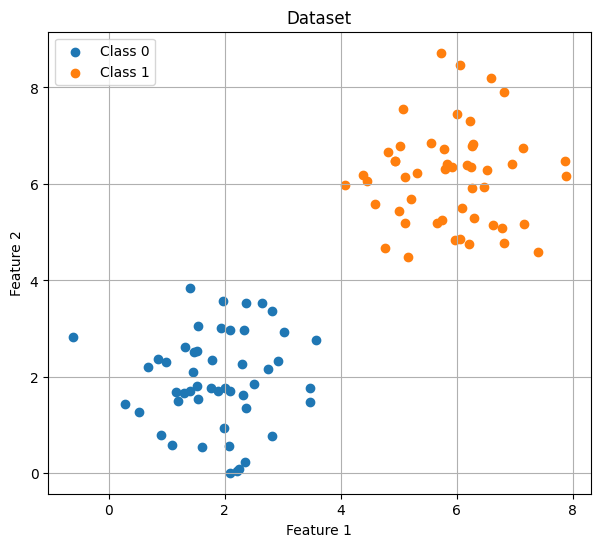

In [3]:
plt.figure(figsize=(7,6))

plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
model = LogisticRegression()
model.fit(X, y)
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [[1.42562352 1.40283684]]
Bias: [-11.2562337]


In [5]:
y_pred = model.predict(X)

print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
probabilities = model.predict_proba(X)

print(probabilities[:5])

[[0.99385008 0.00614992]
 [0.92685752 0.07314248]
 [0.99809541 0.00190459]
 [0.90647752 0.09352248]
 [0.99596008 0.00403992]]


In [7]:
prob_class1 = model.predict_proba(X)[:, 1]

print(prob_class1[:10])

[0.00614992 0.07314248 0.00190459 0.09352248 0.00403992 0.00099347
 0.00035665 0.00014376 0.00135528 0.00013982]


In [8]:
accuracy = accuracy_score(y, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


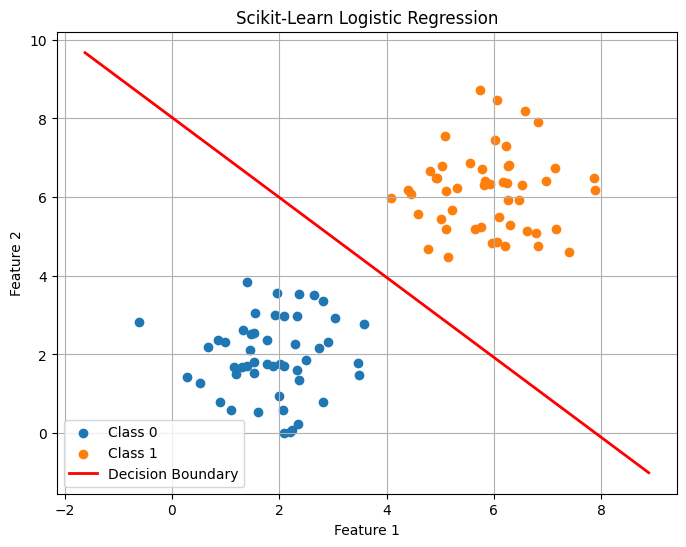

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

x_values = np.array([
    X[:,0].min()-1,
    X[:,0].max()+1
])

coef = model.coef_[0]
intercept = model.intercept_[0]

y_values = -(coef[0] * x_values + intercept) / coef[1]

plt.plot(
    x_values,
    y_values,
    color="red",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scikit-Learn Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
new_samples = np.array([
    [2,2],
    [6,6],
    [3,4],
    [7,5]
])

predictions = model.predict(new_samples)
probabilities = model.predict_proba(new_samples)

for sample, pred, prob in zip(new_samples, predictions, probabilities):
    print(f"Sample: {sample}")
    print(f"Predicted Class: {pred}")
    print(f"Probability Class 0: {prob[0]:.4f}")
    print(f"Probability Class 1: {prob[1]:.4f}")
    print("-" * 40)

Sample: [2 2]
Predicted Class: 0.0
Probability Class 0: 0.9963
Probability Class 1: 0.0037
----------------------------------------
Sample: [6 6]
Predicted Class: 1.0
Probability Class 0: 0.0033
Probability Class 1: 0.9967
----------------------------------------
Sample: [3 4]
Predicted Class: 0.0
Probability Class 0: 0.7971
Probability Class 1: 0.2029
----------------------------------------
Sample: [7 5]
Predicted Class: 1.0
Probability Class 0: 0.0032
Probability Class 1: 0.9968
----------------------------------------
